# Building datasets from measured TESLA cavity data

In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import python libraries and kind framework --!

import torch
import numpy as np

from matplotlib import pyplot as plt

import utils_data

inf >> read data shape is torch.Size([1000000, 2])


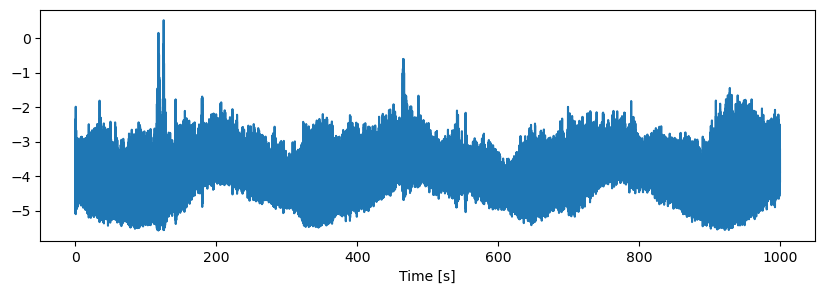

In [2]:
# --! data readout from a file --!

def convert(s):
    """Converts a string ``s`` to a float while replacing commas with dots."""
    s = s.replace(',', '.')
    return float(s)

def read_detuning(name: str, nrow_skip: int=0, delim: str=None):
    return torch.tensor(
        np.loadtxt(
            name,
            delimiter=delim,
            skiprows=nrow_skip,
            dtype=np.float32,
            ndmin=2,
            converters=convert))

dataname = '../../data/baselines/detuning_17072025_15-10_1_QL_4_5e7_KI_0x10000'
rawdata  = read_detuning(dataname, nrow_skip=23, delim='\t')

print(f'inf >> read data shape is {rawdata.shape}')

plt.figure(figsize=(10, 3))
plt.plot(rawdata[:, 0], rawdata[:, 1])
plt.xlabel('Time [s]')
plt.show()

In [3]:
# --! load a trained stationary model --!

model = torch.load('../../models/baselines/tesla_kind_stat.pt', weights_only=False)
model.eval()

model(
  (operator_stat): operator_stationary(
    (fun_enc): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=40, out_features=128, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): ReLU()
        )
        (3): Sequential(
          (0): Linear(in_features=128, out_features=320, bias=True)
          (1): Identity()
        )
      )
    )
    (fun_prune): Linear(in_features=8, out_features=8, bias=False)
    (mod_mean): Linear(in_features=8, out_features=8, bias=False)
    (mod_var): Linear(in_features=8, out_features=8, bias=False)
    (pre_mean_dec): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=8, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequen

In [4]:
# --! define train-test data split --!

test_ratio       = 0.25

rawdata_nsample  = len(rawdata)
test_nsample     = int(test_ratio * rawdata_nsample)
train_nsample    = rawdata_nsample - test_nsample

print(f'inf >> number of training and test samples is {train_nsample} and {test_nsample}, respectively')

inf >> number of training and test samples is 750000 and 250000, respectively


In [5]:
datasaved = False

if datasaved:
    datum            = rawdata[:train_nsample, [1]]
    savedir          = '../../data/baselines/tesla_train_trans'
    utils_data.save_trans(model, savedir, [datum])

In [6]:
datasaved = False

if datasaved:
    timeseries_nsample = model.lookback_nsample + model.forecast_nsample

    savedir_stat  = '../../data/baselines/tesla_train_stat'
    savedir_trans = '../../data/baselines/tesla_train_trans'
    savedir_mixed = '../../data/baselines/tesla_train_mixed'

    utils_data.save_mixed_dataset(savedir_stat, savedir_trans, timeseries_nsample, savedir_mixed)

In [8]:
datasaved = False

if datasaved:
    savedir  = '../../data/baselines/tesla_test'
    filename = 'eval'
    testdata = rawdata[train_nsample:train_nsample+2000, [1]]
    testdata = torch.unsqueeze(testdata, 0)
    utils_data.write_datafile(f'{savedir}/{filename}', testdata)